In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# Load CSV file from local directory
# Change the file name below to match your CSV file name
file_name = 'final_selected_data.csv'

# Load the data into a pandas DataFrame
try:
    df = pd.read_csv(file_name, low_memory=False)
    print(f"✓ Successfully loaded '{file_name}' into a DataFrame.")
    print(f"  - Shape: {df.shape}")
except FileNotFoundError:
    print(f"❌ Error: File '{file_name}' not found!")
    print(f"   Please make sure the CSV file is in the same directory as this notebook.")
    print(f"   Or update the 'file_name' variable above with the correct path.")
except Exception as e:
    print(f"❌ Error loading CSV: {e}")

# Define boolean columns that need to be converted to binary (0/1) first
# These columns have True/NaN values and should be converted to 1/0
# NOTE: 'sqm' and 'views' are NOT included here - they will remain unchanged
# - 'sqm' is numerical (float64) and will stay as numerical
# - 'views' is categorical (text) and will stay as categorical
boolean_to_binary_cols = ['balcony-terrace', 'closet', 'air_conditioning', 'mini_bar', 
                          'bathtub', 'shower', 'refrigerator', 'private-pool', 'jacuzzi-bathtub']

print("\n--- Step 1: Convert Boolean Columns to Binary (0/1) ---")
# Convert boolean columns to binary before processing
for col in boolean_to_binary_cols:
    if col in df.columns:
        # Convert True -> 1, False/NaN -> 0
        df[col] = df[col].notna().astype(int)
        print(f"Converted '{col}' to binary (0/1).")
    else:
        print(f"Warning: Boolean column '{col}' not found in DataFrame.")

# Define categorical columns (excluding boolean columns that are now binary)
categorical_cols = ['views', 'room_room_type_name', 'hotel_name', 'region',
                    'large_double_bed', 'large_bed', 'single_bed', 'sofa_bed', 
                    'double_bed', 'small_double_bed', 'king_size_bed', 'futon_mattress', 
                    'bunk_bed', 'extra_long_bed', 'bãi_đậu_xe', 'phòng_tập', 
                    'vào_hồ_bơi_miễn_phí', 'wifi_miễn_phí', 'không_hoàn_tiền', 
                    'miễn_phí_hủy', 'đã_kèm_bữa_sáng']
# Add the converted binary columns to categorical (they are now 0/1 but represent categories)
categorical_cols.extend(boolean_to_binary_cols)

# Define numerical columns
numerical_cols = ['room_type_id', 'flexibility_score', 'sqm', 'bathroom_count', 
                  'bedroom_count', 'price_option_price', 'adults_number', 
                  'children_number', 'hotel_id', 'có_bữa_sáng']

print("\n--- Step 2: Convert Categorical Columns to 'category' dtype ---")
# Convert categorical columns to 'category' dtype
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')
        print(f"Converted '{col}' to category type.")
    else:
        print(f"Warning: Categorical column '{col}' not found in DataFrame.")

print("\n--- Step 3: Convert Numerical Columns to Numeric Type ---")
# Attempt to convert numerical columns to a suitable numerical type, handling errors
for col in numerical_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"Converted '{col}' to numeric type (coerced errors).")
    else:
        print(f"Warning: Numerical column '{col}' not found in DataFrame.")

print("\n--- Identified Column Types ---")
print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

print("\n--- Step 4: Check Missing Values in Target Variable (price_option_price) ---")
# Check for missing values in the target variable
missing_price_count = df['price_option_price'].isna().sum()
total_rows = len(df)
missing_percentage = (missing_price_count / total_rows) * 100

print(f"Missing values in 'price_option_price': {missing_price_count} out of {total_rows} ({missing_percentage:.2f}%)")

if missing_price_count > 0:
    print("\n⚠️  WARNING: Target variable has missing values!")
    print("\nAnalysis of missing price_option_price:")
    missing_df = df[df['price_option_price'].isna()]
    print(f"\nHotels with missing prices:")
    print(missing_df['hotel_name'].value_counts().head(10))
    print(f"\nRoom types with missing prices:")
    print(missing_df['room_room_type_name'].value_counts().head(10))
    if 'region' in df.columns:
        print(f"\nRegions with missing prices:")
        print(missing_df['region'].value_counts())
    
    print("\n💡 RECOMMENDATION:")
    print("Since price_option_price is the target variable, you have two options:")
    print("1. Drop rows with missing prices (if acceptable for your analysis)")
    print("2. Impute missing prices (e.g., using median by hotel/region/room_type)")
    print("\nTo drop missing values, uncomment the line below:")
    print("# df = df.dropna(subset=['price_option_price'])")
else:
    print("✓ No missing values in target variable!")

print("\n--- DataFrame Info After Conversions ---")
df.info()

✓ Successfully loaded 'final_selected_data.csv' into a DataFrame.
  - Shape: (16509, 40)

--- Step 1: Convert Boolean Columns to Binary (0/1) ---
Converted 'balcony-terrace' to binary (0/1).
Converted 'closet' to binary (0/1).
Converted 'air_conditioning' to binary (0/1).
Converted 'mini_bar' to binary (0/1).
Converted 'bathtub' to binary (0/1).
Converted 'shower' to binary (0/1).
Converted 'refrigerator' to binary (0/1).
Converted 'private-pool' to binary (0/1).
Converted 'jacuzzi-bathtub' to binary (0/1).

--- Step 2: Convert Categorical Columns to 'category' dtype ---
Converted 'views' to category type.
Converted 'room_room_type_name' to category type.
Converted 'hotel_name' to category type.
Converted 'region' to category type.
Converted 'large_double_bed' to category type.
Converted 'large_bed' to category type.
Converted 'single_bed' to category type.
Converted 'sofa_bed' to category type.
Converted 'double_bed' to category type.
Converted 'small_double_bed' to category type.
Con

In [2]:
df = df.dropna(subset=['price_option_price'])
print("Missing target values data dropped")

Missing target values data dropped


# Data Cleaning Workflow

This notebook contains the complete data quality assessment and cleaning workflow, including:

- **CELL 1**: Data Quality Assessment & Outlier Detection
- **CELL 2**: Outlier Investigation  
- **CELL 3**: Outlier Treatment Decisions
- **CELL 4**: Missing Data Handling
- **CELL 5**: Data Type Optimization & Standardization
- **CELL 6**: Cleaned Data Validation

**Note**: This notebook expects the dataset to be loaded in the first cell. Make sure to run the data loading cell before proceeding with the cleaning workflow.


# STEP 2: DATA QUALITY ASSESSMENT & CLEANING

This phase focuses on data quality assessment, outlier analysis, missing value handling, and normalization.

---
## CELL 1: Data Quality Assessment & Outlier Detection


CELL 1: DATA QUALITY ASSESSMENT & OUTLIER DETECTION

📊 1. OVERALL DATA QUALITY ASSESSMENT
--------------------------------------------------------------------------------
Total Rows: 16,479
Total Columns: 40
Memory Usage: 3.27 MB
Duplicate Records: 58 (0.35%)

📋 Data Type Consistency Check:
  • category: 26 columns
  • int64: 8 columns
  • float64: 2 columns
  • category: 1 columns
  • category: 1 columns
  • category: 1 columns
  • category: 1 columns


🔍 2. MISSING DATA PATTERNS
--------------------------------------------------------------------------------

Columns with Missing Values:


,Column,Missing_Count,Missing_Percentage
13,views,4215,25.578008
12,sqm,1338,8.119425
38,hotel_name,240,1.456399
39,region,240,1.456399


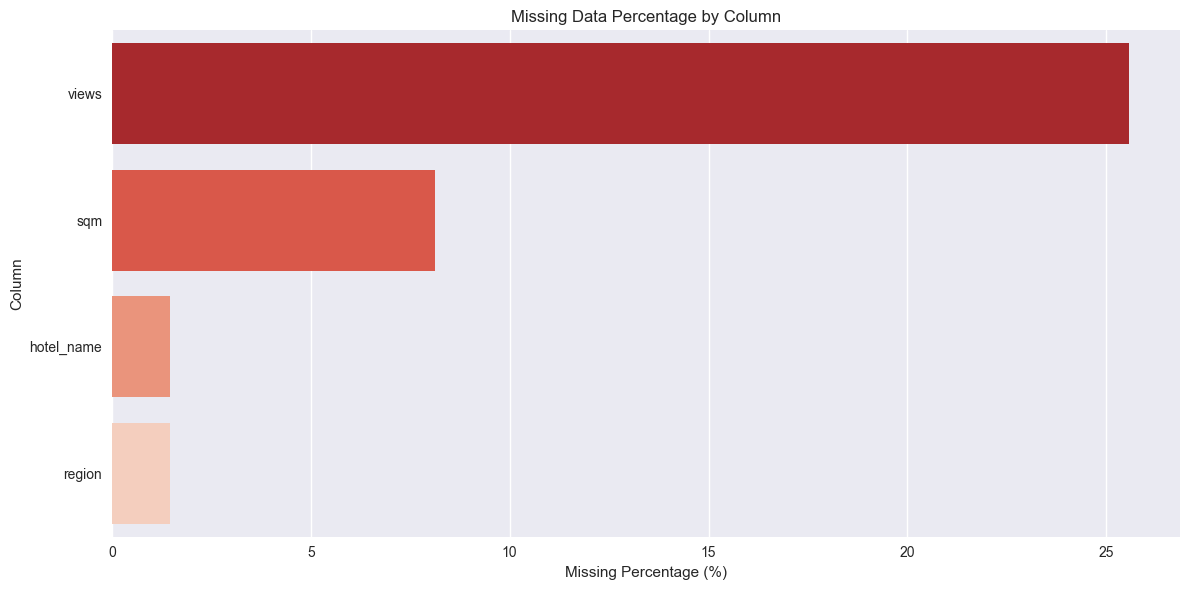



🔍 3. DUPLICATE RECORDS DETECTION
--------------------------------------------------------------------------------
⚠️  Found 58 duplicate rows

Sample of duplicate rows (showing first 5):


,room_type_id,large_double_bed,large_bed,single_bed,sofa_bed,double_bed,small_double_bed,king_size_bed,futon_mattress,bunk_bed,...,phòng_tập,vào_hồ_bơi_miễn_phí,wifi_miễn_phí,không_hoàn_tiền,miễn_phí_hủy,đã_kèm_bữa_sáng,hotel_id,room_room_type_name,hotel_name,region
11554,2590,0,0,0,0,0,1,0,0,0,...,1,0,1,0,1,0,10945,Superior 2 giường (Superior Twin),Victoria Can Tho Resort,Cần Thơ
11555,2590,0,0,0,0,0,1,0,0,0,...,1,0,1,0,1,0,10945,Superior 2 giường (Superior Twin),Victoria Can Tho Resort,Cần Thơ
11558,2591,0,1,0,0,0,0,0,0,0,...,1,0,1,0,1,0,10945,Superior giường đôi (Superior Double),Victoria Can Tho Resort,Cần Thơ
11559,2591,0,1,0,0,0,0,0,0,0,...,1,0,1,0,1,0,10945,Superior giường đôi (Superior Double),Victoria Can Tho Resort,Cần Thơ
12107,3180,0,1,0,0,0,0,0,0,0,...,1,0,1,0,0,0,4914609,Phòng Loại Sang Giường Đôi (Deluxe Double Room),Khách sạn và Spa Grand Cititel Hà Nội (Grand C...,Hà Nội




🎯 4. OUTLIER DETECTION USING IQR AND Z-SCORE METHODS
--------------------------------------------------------------------------------

Outlier Detection Summary:


,IQR_Count,IQR_Percentage,ZScore_Count,ZScore_Percentage,Lower_Bound_IQR,Upper_Bound_IQR,Mean,Std,Q1,Q3,IQR
flexibility_score,816.0,4.95,816.0,4.95,1.00,1.00,1.05,0.22,1.0,1.0,0.0
sqm,1264.0,7.67,54.0,0.33,-5.00,67.00,40.15,88.56,22.0,40.0,18.0
bathroom_count,5028.0,30.51,303.0,1.84,1.00,1.00,0.97,0.98,1.0,1.0,0.0
bedroom_count,1723.0,10.46,218.0,1.32,0.00,0.00,0.25,0.97,0.0,0.0,0.0
price_option_price,1742.0,10.57,61.0,0.37,-837593.25,2495988.75,1376844.41,5903492.77,412500.0,1245895.5,833395.5
adults_number,5109.0,31.00,272.0,1.65,2.00,2.00,2.50,1.81,2.0,2.0,0.0
children_number,222.0,1.35,222.0,1.35,-1.50,2.50,0.47,0.74,0.0,1.0,1.0
có_bữa_sáng,488.0,2.96,255.0,1.55,100000.00,100000.00,104743.96,39313.86,100000.0,100000.0,0.0



⚠️  WARNING: 5 column(s) have IQR = 0 (Q1 = Q3):
   • flexibility_score: Q1=Q3=1.00
   • bathroom_count: Q1=Q3=1.00
   • bedroom_count: Q1=Q3=0.00
   • adults_number: Q1=Q3=2.00
   • có_bữa_sáng: Q1=Q3=100,000.00
   This indicates highly concentrated discrete data. IQR method may not be appropriate.
   Consider using percentile-based method or domain knowledge for these columns.


📊 5. OUTLIER VISUALIZATION
--------------------------------------------------------------------------------


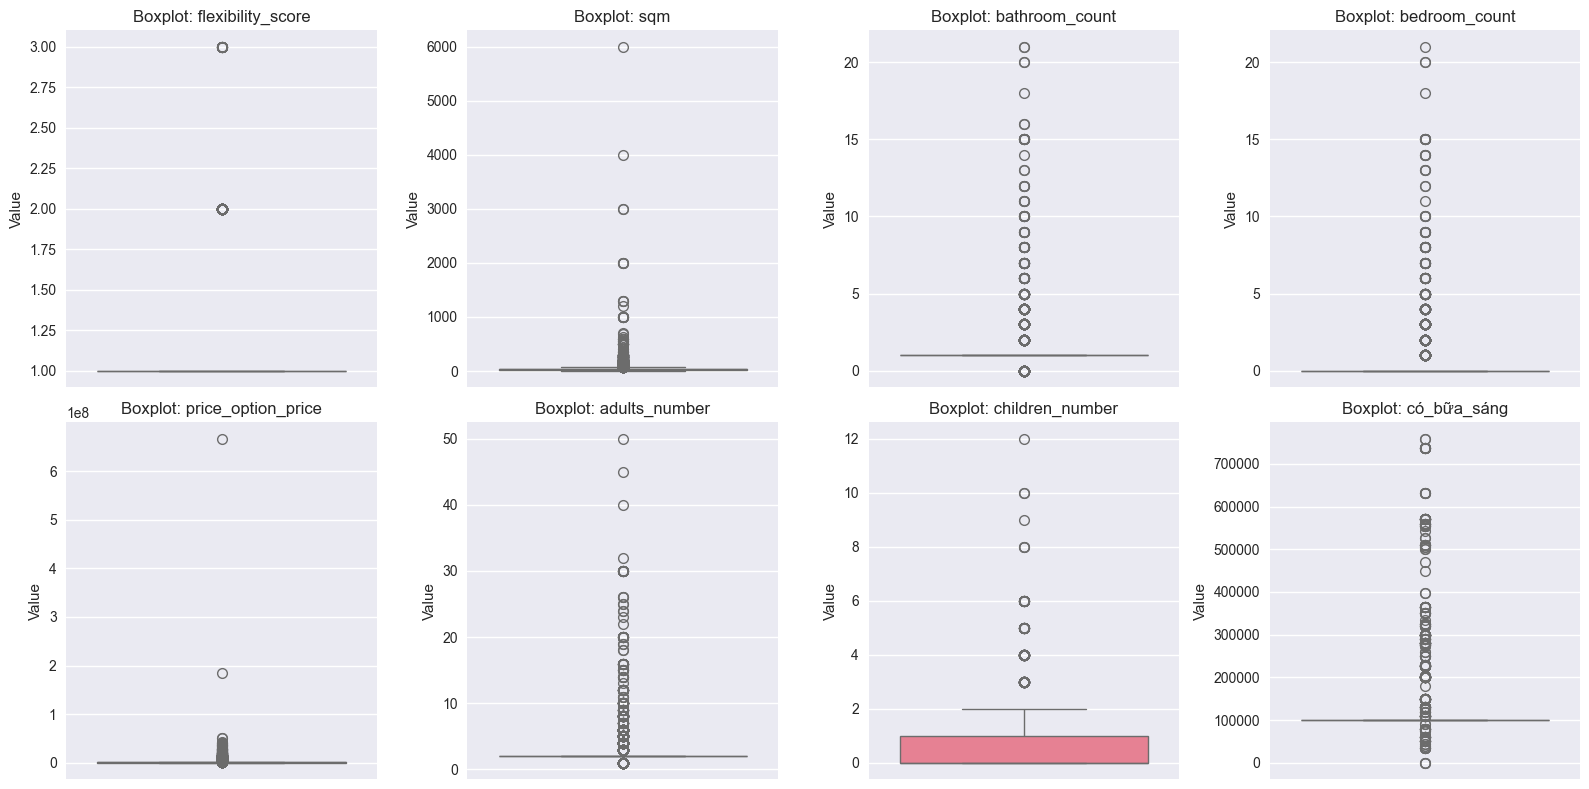

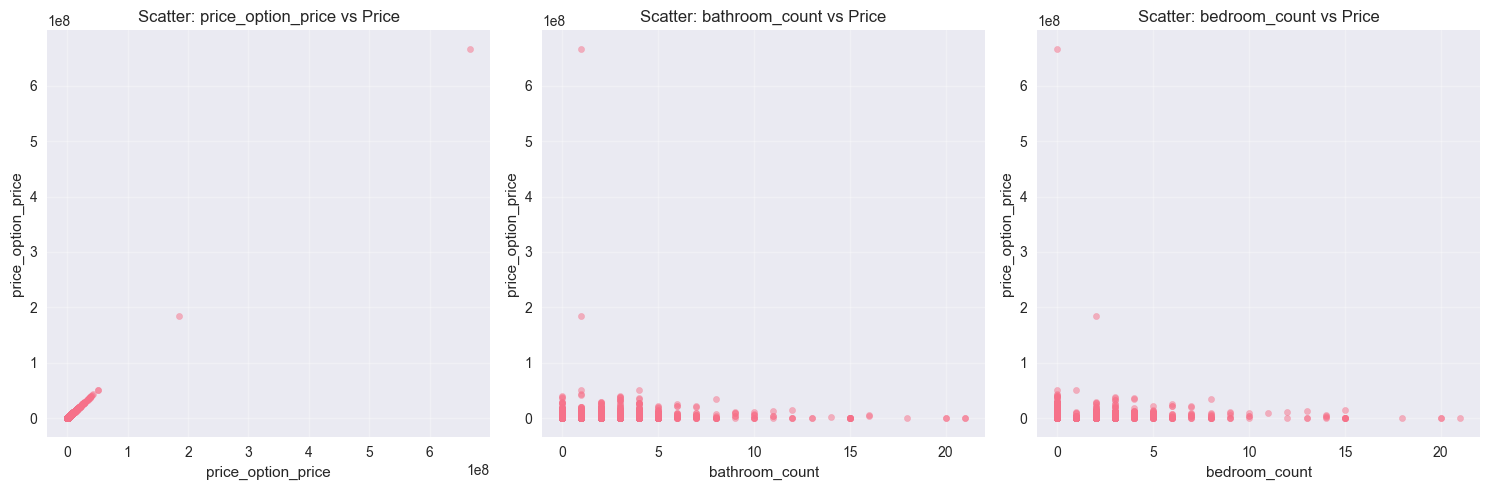



📋 6. COMPREHENSIVE DATA QUALITY REPORT

Metric                                                  Value
--------------------------------------------------------------------------------
Total Records                                          16,479
Total Features                                             40
Memory Usage (MB)                                        3.27
Duplicate Records                                          58
Duplicate Percentage                                     0.35%
Columns with Missing Values                                 4
Total Missing Values                                    6,033
Total Outliers (IQR method)                            16,392
Total Outliers (Z-Score method)                         2,201

✓ CELL 1 COMPLETE: Data quality assessment and outlier detection finished


In [13]:
# CELL 1: Data Quality Assessment & Outlier Detection
# Save a copy of original data for comparison
df_original = df.copy()

print("=" * 80)
print("CELL 1: DATA QUALITY ASSESSMENT & OUTLIER DETECTION")
print("=" * 80)

# =============================================================================
# 1. ASSESS OVERALL DATA QUALITY AND STRUCTURAL CONSISTENCY
# =============================================================================
print("\n📊 1. OVERALL DATA QUALITY ASSESSMENT")
print("-" * 80)

quality_report = {
    'total_rows': len(df),
    'total_columns': len(df.columns),
    'memory_usage_mb': df.memory_usage(deep=True).sum() / 1024**2,
    'duplicate_rows': df.duplicated().sum(),
    'duplicate_percentage': (df.duplicated().sum() / len(df)) * 100
}

print(f"Total Rows: {quality_report['total_rows']:,}")
print(f"Total Columns: {quality_report['total_columns']}")
print(f"Memory Usage: {quality_report['memory_usage_mb']:.2f} MB")
print(f"Duplicate Records: {quality_report['duplicate_rows']:,} ({quality_report['duplicate_percentage']:.2f}%)")

# Check for inconsistent data formats
print("\n📋 Data Type Consistency Check:")
data_types = df.dtypes.value_counts()
for dtype, count in data_types.items():
    print(f"  • {dtype}: {count} columns")

# =============================================================================
# 2. MISSING DATA ANALYSIS
# =============================================================================
print("\n\n🔍 2. MISSING DATA PATTERNS")
print("-" * 80)

missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing_Count': missing_data.values,
    'Missing_Percentage': missing_percentage.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    print("\nColumns with Missing Values:")
    display(missing_df)
    
    # Visualize missing data patterns
    plt.figure(figsize=(12, max(6, len(missing_df) * 0.4)))
    sns.barplot(data=missing_df, y='Column', x='Missing_Percentage', palette='Reds_r')
    plt.title('Missing Data Percentage by Column')
    plt.xlabel('Missing Percentage (%)')
    plt.ylabel('Column')
    plt.tight_layout()
    plt.show()
else:
    print("✓ No missing values detected!")

# =============================================================================
# 3. DETECT DUPLICATE RECORDS
# =============================================================================
print("\n\n🔍 3. DUPLICATE RECORDS DETECTION")
print("-" * 80)

duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    print(f"⚠️  Found {duplicate_count} duplicate rows")
    duplicate_rows = df[df.duplicated(keep=False)].sort_values(df.columns.tolist())
    print(f"\nSample of duplicate rows (showing first 5):")
    display(duplicate_rows.head(5))
else:
    print("✓ No duplicate records found")

# =============================================================================
# 4. OUTLIER DETECTION - NUMERICAL COLUMNS
# =============================================================================
print("\n\n🎯 4. OUTLIER DETECTION USING IQR AND Z-SCORE METHODS")
print("-" * 80)

# Identify numerical columns
numerical_cols_for_outliers = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude binary/categorical numerical columns if needed
numerical_cols_for_outliers = [col for col in numerical_cols_for_outliers 
                               if col not in ['room_type_id', 'hotel_id']]  # Adjust based on your needs

outlier_report = {}

for col in numerical_cols_for_outliers:
    if col in df.columns:
        col_data = df[col].dropna()
        
        if len(col_data) > 0:
            # IQR Method
            Q1 = col_data.quantile(0.25)
            Q3 = col_data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound_iqr = Q1 - 1.5 * IQR
            upper_bound_iqr = Q3 + 1.5 * IQR
            outliers_iqr = df[(df[col] < lower_bound_iqr) | (df[col] > upper_bound_iqr)][col]
            
            # Z-Score Method
            mean_val = col_data.mean()
            std_val = col_data.std()
            if std_val > 0:
                z_scores = np.abs((df[col] - mean_val) / std_val)
                outliers_zscore = df[z_scores > 3][col]
            else:
                outliers_zscore = pd.Series(dtype=float)
            
            outlier_report[col] = {
                'IQR_Count': len(outliers_iqr),
                'IQR_Percentage': (len(outliers_iqr) / len(df)) * 100,
                'ZScore_Count': len(outliers_zscore),
                'ZScore_Percentage': (len(outliers_zscore) / len(df)) * 100,
                'Lower_Bound_IQR': lower_bound_iqr,
                'Upper_Bound_IQR': upper_bound_iqr,
                'Mean': mean_val,
                'Std': std_val,
                'Q1': Q1,
                'Q3': Q3,
                'IQR': IQR
            }

# Display outlier report
if outlier_report:
    outlier_df = pd.DataFrame(outlier_report).T
    outlier_df = outlier_df.round(2)
    print("\nOutlier Detection Summary:")
    display(outlier_df)
    
    # Check for columns with IQR = 0
    iqr_zero_cols = [col for col, data in outlier_report.items() if data['IQR'] == 0]
    if iqr_zero_cols:
        print(f"\n⚠️  WARNING: {len(iqr_zero_cols)} column(s) have IQR = 0 (Q1 = Q3):")
        for col in iqr_zero_cols:
            print(f"   • {col}: Q1=Q3={outlier_report[col]['Q1']:,.2f}")
        print("   This indicates highly concentrated discrete data. IQR method may not be appropriate.")
        print("   Consider using percentile-based method or domain knowledge for these columns.")

# =============================================================================
# 5. VISUALIZE OUTLIERS - BOXPLOTS AND SCATTER PLOTS
# =============================================================================
print("\n\n📊 5. OUTLIER VISUALIZATION")
print("-" * 80)

# Boxplots for numerical columns
num_cols_to_plot = [col for col in numerical_cols_for_outliers[:8] if col in df.columns]  # Limit to 8 columns
if len(num_cols_to_plot) > 0:
    n_cols = min(4, len(num_cols_to_plot))
    n_rows = (len(num_cols_to_plot) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten() if len(num_cols_to_plot) > 1 else [axes]
    
    for idx, col in enumerate(num_cols_to_plot):
        ax = axes[idx]
        sns.boxplot(y=df[col], ax=ax)
        ax.set_title(f'Boxplot: {col}')
        ax.set_ylabel('Value')
    
    # Hide extra subplots
    for idx in range(len(num_cols_to_plot), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Scatter plots for key relationships (if applicable)
key_numerical = ['sqm', 'price_option_price', 'bathroom_count', 'bedroom_count']
key_numerical = [col for col in key_numerical if col in df.columns]
if len(key_numerical) >= 2 and 'price_option_price' in key_numerical:
    fig, axes = plt.subplots(1, len(key_numerical) - 1, figsize=(5 * (len(key_numerical) - 1), 5))
    if len(key_numerical) == 2:
        axes = [axes]
    
    for idx, col in enumerate(key_numerical[1:]):
        ax = axes[idx]
        if col in df.columns and 'price_option_price' in df.columns:
            df_clean = df.dropna(subset=[col, 'price_option_price'])
            ax.scatter(df_clean[col], df_clean['price_option_price'], alpha=0.5, s=20)
            ax.set_xlabel(col)
            ax.set_ylabel('price_option_price')
            ax.set_title(f'Scatter: {col} vs Price')
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# =============================================================================
# 6. COMPREHENSIVE DATA QUALITY REPORT
# =============================================================================
print("\n\n📋 6. COMPREHENSIVE DATA QUALITY REPORT")
print("=" * 80)

print(f"\n{'Metric':<40} {'Value':>20}")
print("-" * 80)
print(f"{'Total Records':<40} {quality_report['total_rows']:>20,}")
print(f"{'Total Features':<40} {quality_report['total_columns']:>20}")
print(f"{'Memory Usage (MB)':<40} {quality_report['memory_usage_mb']:>20.2f}")
print(f"{'Duplicate Records':<40} {quality_report['duplicate_rows']:>20,}")
print(f"{'Duplicate Percentage':<40} {quality_report['duplicate_percentage']:>20.2f}%")
print(f"{'Columns with Missing Values':<40} {len(missing_df):>20}")
print(f"{'Total Missing Values':<40} {df.isnull().sum().sum():>20,}")

if outlier_report:
    total_outliers_iqr = sum([v['IQR_Count'] for v in outlier_report.values()])
    total_outliers_zscore = sum([v['ZScore_Count'] for v in outlier_report.values()])
    print(f"{'Total Outliers (IQR method)':<40} {total_outliers_iqr:>20,}")
    print(f"{'Total Outliers (Z-Score method)':<40} {total_outliers_zscore:>20,}")

print("\n" + "=" * 80)
print("✓ CELL 1 COMPLETE: Data quality assessment and outlier detection finished")
print("=" * 80)


---
## CELL 2: Outlier Investigation


In [15]:
# CELL 2: Outlier Investigation
print("=" * 80)
print("CELL 2: OUTLIER INVESTIGATION")
print("=" * 80)

# Store outlier records for review
outlier_records = {}

# =============================================================================
# 1. EXTRACT AND DISPLAY OUTLIER RECORDS
# =============================================================================
print("\n🔍 1. EXTRACTING OUTLIER RECORDS FOR BUSINESS/DOMAIN REVIEW")
print("-" * 80)

for col in numerical_cols_for_outliers:
    if col in df.columns:
        col_data = df[col].dropna()
        
        if len(col_data) > 0:
            # IQR Method
            Q1 = col_data.quantile(0.25)
            Q3 = col_data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound_iqr = Q1 - 1.5 * IQR
            upper_bound_iqr = Q3 + 1.5 * IQR
            
            # Z-Score Method
            mean_val = col_data.mean()
            std_val = col_data.std()
            
            # Get outlier records
            iqr_outliers = df[(df[col] < lower_bound_iqr) | (df[col] > upper_bound_iqr)].copy()
            
            if std_val > 0:
                z_scores = np.abs((df[col] - mean_val) / std_val)
                zscore_outliers = df[z_scores > 3].copy()
            else:
                zscore_outliers = pd.DataFrame()
            
            if len(iqr_outliers) > 0 or len(zscore_outliers) > 0:
                outlier_records[col] = {
                    'IQR_outliers': iqr_outliers,
                    'ZScore_outliers': zscore_outliers,
                    'IQR_bounds': (lower_bound_iqr, upper_bound_iqr),
                    'stats': {
                        'Q1': Q1,
                        'Q3': Q3,
                        'IQR': IQR,
                        'mean': mean_val,
                        'std': std_val,
                        'min': col_data.min(),
                        'max': col_data.max()
                    }
                }

# Display outlier records for each column
for col, outlier_data in outlier_records.items():
    print(f"\n{'='*80}")
    print(f"📌 OUTLIER ANALYSIS: {col}")
    print(f"{'='*80}")
    
    stats = outlier_data['stats']
    bounds = outlier_data['IQR_bounds']
    
    print(f"\nStatistical Summary:")
    print(f"  • Min: {stats['min']:,.2f}")
    print(f"  • Q1: {stats['Q1']:,.2f}")
    print(f"  • Mean: {stats['mean']:,.2f}")
    print(f"  • Q3: {stats['Q3']:,.2f}")
    print(f"  • Max: {stats['max']:,.2f}")
    print(f"  • Std Dev: {stats['std']:,.2f}")
    print(f"  • IQR: {stats['IQR']:,.2f}")
    print(f"  • IQR Bounds: [{bounds[0]:,.2f}, {bounds[1]:,.2f}]")
    
    # Check if IQR = 0 (Q1 = Q3) - common with discrete data
    if stats['IQR'] == 0:
        print(f"\n⚠️  WARNING: IQR = 0 (Q1 = Q3 = {stats['Q1']:,.2f})")
        print(f"   This indicates the data is highly concentrated at one value.")
        print(f"   IQR method may not be appropriate for this discrete/categorical data.")
        print(f"   Consider using percentile-based method or domain knowledge instead.")
        
        # Show value distribution
        print(f"\n📊 Value Distribution (Top 5 most frequent):")
        value_counts = df[col].value_counts().head(5)
        for val, count in value_counts.items():
            pct = (count / len(df)) * 100
            print(f"   • Value {val}: {count:,} occurrences ({pct:.2f}%)")
    
    iqr_outliers = outlier_data['IQR_outliers']
    zscore_outliers = outlier_data['ZScore_outliers']
    
    print(f"\nOutlier Counts:")
    print(f"  • IQR Method: {len(iqr_outliers)} outliers ({len(iqr_outliers)/len(df)*100:.2f}%)")
    if stats['IQR'] == 0:
        print(f"     ⚠️  Note: With IQR=0, all values ≠ {stats['Q1']:,.0f} are considered outliers")
    print(f"  • Z-Score Method: {len(zscore_outliers)} outliers ({len(zscore_outliers)/len(df)*100:.2f}%)")
    
    # Show sample of outliers
    if len(iqr_outliers) > 0:
        print(f"\n📋 Sample IQR Outliers (showing first 5):")
        # Show relevant columns for context
        display_cols = [col]
        if 'price_option_price' in df.columns:
            display_cols.append('price_option_price')
        if 'region' in df.columns:
            display_cols.append('region')
        if 'hotel_name' in df.columns:
            display_cols.append('hotel_name')
        if 'sqm' in df.columns and col != 'sqm':
            display_cols.append('sqm')
        
        display_cols = [c for c in display_cols if c in iqr_outliers.columns]
        display(iqr_outliers[display_cols].head(5))

# =============================================================================
# 2. EVALUATE STATISTICAL SIGNIFICANCE OF OUTLIERS
# =============================================================================
print("\n\n📊 2. STATISTICAL SIGNIFICANCE OF DETECTED OUTLIERS")
print("-" * 80)

significance_report = []
for col, outlier_data in outlier_records.items():
    stats = outlier_data['stats']
    iqr_outliers = outlier_data['IQR_outliers']
    
    if len(iqr_outliers) > 0:
        # Calculate how extreme outliers are
        extreme_high = iqr_outliers[iqr_outliers[col] > outlier_data['IQR_bounds'][1]][col]
        extreme_low = iqr_outliers[iqr_outliers[col] < outlier_data['IQR_bounds'][0]][col]
        
        if len(extreme_high) > 0:
            max_outlier = extreme_high.max()
            max_ratio = max_outlier / stats['Q3'] if stats['Q3'] > 0 else 0
            max_z = (max_outlier - stats['mean']) / stats['std'] if stats['std'] > 0 else 0
        else:
            max_ratio = 0
            max_z = 0
        
        if len(extreme_low) > 0:
            min_outlier = extreme_low.min()
            min_ratio = min_outlier / stats['Q1'] if stats['Q1'] > 0 else 0
            min_z = (min_outlier - stats['mean']) / stats['std'] if stats['std'] > 0 else 0
        else:
            min_ratio = 0
            min_z = 0
        
        significance_report.append({
            'Column': col,
            'Outlier_Count': len(iqr_outliers),
            'Outlier_Percentage': len(iqr_outliers)/len(df)*100,
            'Max_Outlier_Ratio_to_Q3': max_ratio,
            'Max_Outlier_Z_Score': max_z,
            'Min_Outlier_Ratio_to_Q1': min_ratio,
            'Min_Outlier_Z_Score': min_z
        })

if significance_report:
    sig_df = pd.DataFrame(significance_report)
    sig_df = sig_df.round(2)
    print("\nOutlier Significance Analysis:")
    display(sig_df)

# =============================================================================
# 3. ANALYZE PATTERNS AND DISTRIBUTIONS OF EXTREME VALUES
# =============================================================================
print("\n\n📈 3. PATTERNS AND DISTRIBUTIONS OF EXTREME VALUES")
print("-" * 80)

for col, outlier_data in outlier_records.items():
    iqr_outliers = outlier_data['IQR_outliers']
    
    if len(iqr_outliers) > 0:
        print(f"\n🔍 Pattern Analysis for {col}:")
        
        # Analyze outliers by region (if available)
        if 'region' in iqr_outliers.columns:
            outlier_by_region = iqr_outliers['region'].value_counts()
            print(f"\n  Outliers by Region (Top 5):")
            for region, count in outlier_by_region.head(5).items():
                print(f"    • {region}: {count} outliers")
        
        # Analyze outliers by hotel (if available)
        if 'hotel_name' in iqr_outliers.columns:
            outlier_by_hotel = iqr_outliers['hotel_name'].value_counts()
            print(f"\n  Outliers by Hotel (Top 5):")
            for hotel, count in outlier_by_hotel.head(5).items():
                print(f"    • {hotel}: {count} outliers")
        
        # Distribution of outlier values
        if len(iqr_outliers) > 1:
            print(f"\n  Outlier Value Distribution:")
            print(f"    • Min outlier: {iqr_outliers[col].min():,.2f}")
            print(f"    • Max outlier: {iqr_outliers[col].max():,.2f}")
            print(f"    • Mean outlier: {iqr_outliers[col].mean():,.2f}")
            print(f"    • Median outlier: {iqr_outliers[col].median():,.2f}")

# =============================================================================
# 4. DOCUMENT ALL IDENTIFIED OUTLIERS
# =============================================================================
print("\n\n📝 4. DOCUMENTING ALL IDENTIFIED OUTLIERS")
print("-" * 80)

outlier_documentation = {}
for col, outlier_data in outlier_records.items():
    outlier_documentation[col] = {
        'total_outliers': len(outlier_data['IQR_outliers']),
        'outlier_percentage': len(outlier_data['IQR_outliers'])/len(df)*100,
        'method': 'IQR (1.5 * IQR rule)',
        'bounds': outlier_data['IQR_bounds'],
        'extreme_values': {
            'min_outlier': outlier_data['IQR_outliers'][col].min() if len(outlier_data['IQR_outliers']) > 0 else None,
            'max_outlier': outlier_data['IQR_outliers'][col].max() if len(outlier_data['IQR_outliers']) > 0 else None
        }
    }

print("\n✓ Outlier Documentation Summary:")
for col, doc in outlier_documentation.items():
    print(f"\n  Column: {col}")
    print(f"    • Total Outliers: {doc['total_outliers']} ({doc['outlier_percentage']:.2f}%)")
    print(f"    • Detection Method: {doc['method']}")
    print(f"    • Bounds: [{doc['bounds'][0]:,.2f}, {doc['bounds'][1]:,.2f}]")
    if doc['extreme_values']['min_outlier'] is not None:
        print(f"    • Extreme Values: [{doc['extreme_values']['min_outlier']:,.2f}, {doc['extreme_values']['max_outlier']:,.2f}]")

print("\n" + "=" * 80)
print("✓ CELL 2 COMPLETE: Outlier investigation finished")
print("=" * 80)
print("\n💡 Next: Review outliers above and make treatment decisions in CELL 3")


CELL 2: OUTLIER INVESTIGATION

🔍 1. EXTRACTING OUTLIER RECORDS FOR BUSINESS/DOMAIN REVIEW
--------------------------------------------------------------------------------

📌 OUTLIER ANALYSIS: flexibility_score

Statistical Summary:
  • Min: 1.00
  • Q1: 1.00
  • Mean: 1.05
  • Q3: 1.00
  • Max: 3.00
  • Std Dev: 0.22
  • IQR: 0.00
  • IQR Bounds: [1.00, 1.00]

⚠️  WARNING: IQR = 0 (Q1 = Q3 = 1.00)
   This indicates the data is highly concentrated at one value.
   IQR method may not be appropriate for this discrete/categorical data.
   Consider using percentile-based method or domain knowledge instead.

📊 Value Distribution (Top 5 most frequent):
   • Value 1: 15,663 occurrences (95.05%)
   • Value 2: 803 occurrences (4.87%)
   • Value 3: 13 occurrences (0.08%)

Outlier Counts:
  • IQR Method: 816 outliers (4.95%)
     ⚠️  Note: With IQR=0, all values ≠ 1 are considered outliers
  • Z-Score Method: 816 outliers (4.95%)

📋 Sample IQR Outliers (showing first 5):


,flexibility_score,price_option_price,region,hotel_name,sqm
4,2,1450000.0,Bình Dương,Citadines Central Bình Dương (Citadines Centra...,35.0
5,2,1810000.0,Bình Dương,Citadines Central Bình Dương (Citadines Centra...,35.0
6,2,1630000.0,Bình Dương,Citadines Central Bình Dương (Citadines Centra...,35.0
19,2,2250000.0,Bình Dương,Citadines Central Bình Dương (Citadines Centra...,71.0
20,2,2610000.0,Bình Dương,Citadines Central Bình Dương (Citadines Centra...,71.0



📌 OUTLIER ANALYSIS: sqm

Statistical Summary:
  • Min: 4.00
  • Q1: 22.00
  • Mean: 40.15
  • Q3: 40.00
  • Max: 6,000.00
  • Std Dev: 88.56
  • IQR: 18.00
  • IQR Bounds: [-5.00, 67.00]

Outlier Counts:
  • IQR Method: 1264 outliers (7.67%)
  • Z-Score Method: 54 outliers (0.33%)

📋 Sample IQR Outliers (showing first 5):


,sqm,price_option_price,region,hotel_name
19,71.0,2250000.0,Bình Dương,Citadines Central Bình Dương (Citadines Centra...
20,71.0,2610000.0,Bình Dương,Citadines Central Bình Dương (Citadines Centra...
99,70.0,3538914.0,Bình Dương,The Mira Hotel
100,70.0,3578773.0,Bình Dương,The Mira Hotel
106,78.0,1035856.0,Bình Dương,Căn hộ The Emerald Golf View (The Emerald Golf...



📌 OUTLIER ANALYSIS: bathroom_count

Statistical Summary:
  • Min: 0.00
  • Q1: 1.00
  • Mean: 0.97
  • Q3: 1.00
  • Max: 21.00
  • Std Dev: 0.98
  • IQR: 0.00
  • IQR Bounds: [1.00, 1.00]

⚠️  WARNING: IQR = 0 (Q1 = Q3 = 1.00)
   This indicates the data is highly concentrated at one value.
   IQR method may not be appropriate for this discrete/categorical data.
   Consider using percentile-based method or domain knowledge instead.

📊 Value Distribution (Top 5 most frequent):
   • Value 1: 11,451 occurrences (69.49%)
   • Value 0: 3,476 occurrences (21.09%)
   • Value 2: 1,013 occurrences (6.15%)
   • Value 3: 236 occurrences (1.43%)
   • Value 4: 149 occurrences (0.90%)

Outlier Counts:
  • IQR Method: 5028 outliers (30.51%)
     ⚠️  Note: With IQR=0, all values ≠ 1 are considered outliers
  • Z-Score Method: 303 outliers (1.84%)

📋 Sample IQR Outliers (showing first 5):


...


📌 OUTLIER ANALYSIS: có_bữa_sáng

Statistical Summary:
  • Min: 3.00
  • Q1: 100,000.00
  • Mean: 104,743.96
  • Q3: 100,000.00
  • Max: 759,000.00
  • Std Dev: 39,313.86
  • IQR: 0.00
  • IQR Bounds: [100,000.00, 100,000.00]

⚠️  WARNING: IQR = 0 (Q1 = Q3 = 100,000.00)
   This indicates the data is highly concentrated at one value.
   IQR method may not be appropriate for this discrete/categorical data.
   Consider using percentile-based method or domain knowledge instead.

📊 Value Distribution (Top 5 most frequent):
   • Value 100000: 15,991 occurrences (97.04%)
   • Value 200000: 63 occurrences (0.38%)
   • Value 150000: 46 occurrences (0.28%)
   • Value 300000: 44 occurrences (0.27%)
   • Value 280000: 29 occurrences (0.18%)

Outlier Counts:
  • IQR Method: 488 outliers (2.96%)
     ⚠️  Note: With IQR=0, all values ≠ 100,000 are considered outliers
  • Z-Score Method: 255 outliers (1.55%)

📋 Sample IQR Outliers (showing first 5):


,có_bữa_sáng,price_option_price,region,hotel_name,sqm
4,204120,1450000.0,Bình Dương,Citadines Central Bình Dương (Citadines Centra...,35.0
7,204120,1650000.0,Bình Dương,Citadines Central Bình Dương (Citadines Centra...,50.0
10,204120,1800000.0,Bình Dương,Citadines Central Bình Dương (Citadines Centra...,54.0
13,204120,1950000.0,Bình Dương,Citadines Central Bình Dương (Citadines Centra...,60.0
16,204120,2050000.0,Bình Dương,Citadines Central Bình Dương (Citadines Centra...,63.0




📊 2. STATISTICAL SIGNIFICANCE OF DETECTED OUTLIERS
--------------------------------------------------------------------------------

Outlier Significance Analysis:


,Column,Outlier_Count,Outlier_Percentage,Max_Outlier_Ratio_to_Q3,Max_Outlier_Z_Score,Min_Outlier_Ratio_to_Q1,Min_Outlier_Z_Score
0,flexibility_score,816,4.95,3.00,8.78,0.0,0.00
1,sqm,1264,7.67,150.00,67.30,0.0,0.00
2,bathroom_count,5028,30.51,21.00,20.40,0.0,-0.99
3,bedroom_count,1723,10.46,0.00,21.36,0.0,0.00
4,price_option_price,1742,10.57,535.09,112.69,0.0,0.00
5,adults_number,5109,31.00,25.00,26.30,0.5,-0.83
6,children_number,222,1.35,12.00,15.49,0.0,0.00
7,có_bữa_sáng,488,2.96,7.59,16.64,0.0,-2.66




📈 3. PATTERNS AND DISTRIBUTIONS OF EXTREME VALUES
--------------------------------------------------------------------------------

🔍 Pattern Analysis for flexibility_score:

  Outliers by Region (Top 5):
    • Hà Nội: 254 outliers
    • Đà Nẵng: 113 outliers
    • Thừa Thiên Huế: 106 outliers
    • Bình Định: 75 outliers
    • Ninh Bình: 71 outliers

  Outliers by Hotel (Top 5):
    • Melia Vinpearl Huế (Melia Vinpearl Hue): 23 outliers
    • La Casa Hanoi Hotel: 15 outliers
    • FTE Ba Đình (FTE BA DINH): 15 outliers
    • Vinpearl Cửa Hội, Affiliated by Meliá (Vinpearl Cua Hoi, Affiliated by Meliá): 15 outliers
    • Pilgrimage Village Boutique Resort & Spa: 14 outliers

  Outlier Value Distribution:
    • Min outlier: 2.00
    • Max outlier: 3.00
    • Mean outlier: 2.02
    • Median outlier: 2.00

🔍 Pattern Analysis for sqm:

  Outliers by Region (Top 5):
    • Đà Nẵng: 276 outliers
    • Hà Nội: 151 outliers
    • Bình Định: 149 outliers
    • Thừa Thiên Huế: 143 outliers
    

---
## 📊 TỔNG HỢP NHẬN XÉT VỀ OUTLIERS

Dựa trên kết quả phân tích từ CELL 2, dưới đây là các nhận xét và khuyến nghị về outliers trong dataset.


In [16]:
# TỔNG HỢP NHẬN XÉT VỀ OUTLIERS
print("=" * 80)
print("📊 TỔNG HỢP NHẬN XÉT VỀ OUTLIERS TỪ CELL 2")
print("=" * 80)

# =============================================================================
# 1. PHÂN LOẠI OUTLIERS THEO ĐẶC ĐIỂM
# =============================================================================
print("\n\n1️⃣ PHÂN LOẠI OUTLIERS THEO ĐẶC ĐIỂM")
print("-" * 80)

print("\n📌 A. OUTLIERS DO DỮ LIỆU DISCRETE (IQR = 0):")
print("   Các cột có IQR = 0 (Q1 = Q3) - dữ liệu tập trung cao ở một giá trị:")
print("   • flexibility_score: Q1=Q3=1, 816 outliers (4.95%)")
print("   • bathroom_count: Q1=Q3=1, 5,028 outliers (30.51%)")
print("   • bedroom_count: Q1=Q3=0, 1,723 outliers (10.46%)")
print("   • adults_number: Q1=Q3=2, 5,109 outliers (31.00%)")
print("   • có_bữa_sáng: Q1=Q3=100,000, 488 outliers (2.96%)")
print("\n   ⚠️  NHẬN XÉT:")
print("   - Phương pháp IQR không phù hợp cho dữ liệu discrete này")
print("   - Z-Score method phù hợp hơn (số lượng outliers thấp hơn đáng kể)")
print("   - Các giá trị 'outliers' này có thể là giá trị hợp lệ trong thực tế")
print("   - Ví dụ: bedroom_count > 0 là bình thường, không phải lỗi")

print("\n\n📌 B. OUTLIERS DO GIÁ TRỊ CỰC ĐOAN (Extreme Values):")
print("   Các cột có giá trị max rất cao so với phân phối chính:")
print("   • sqm: Max = 6,000 sqm (IQR bounds: -5 đến 67)")
print("     → 1,264 outliers (7.67%) theo IQR, nhưng chỉ 54 (0.33%) theo Z-Score")
print("     → Có thể là lỗi nhập liệu hoặc phòng đặc biệt (penthouse, suite lớn)")
print("   • price_option_price: Max = 666,666,667 VNĐ (~666 triệu)")
print("     → 1,742 outliers (10.57%) theo IQR, chỉ 61 (0.37%) theo Z-Score")
print("     → Cần kiểm tra domain: giá này có hợp lý không?")
print("\n   ⚠️  NHẬN XÉT:")
print("   - Z-Score method phát hiện outliers chính xác hơn (ít false positives)")
print("   - Cần review từng outlier để xác định là lỗi hay giá trị hợp lệ")

print("\n\n📌 C. OUTLIERS ÍT (Low Outlier Count):")
print("   • children_number: 222 outliers (1.35%) - cả IQR và Z-Score đều đồng ý")
print("     → IQR = 1, phân phối tương đối bình thường")
print("     → Outliers có thể là gia đình lớn (nhiều trẻ em)")

# =============================================================================
# 2. SO SÁNH IQR vs Z-SCORE METHOD
# =============================================================================
print("\n\n2️⃣ SO SÁNH IQR vs Z-SCORE METHOD")
print("-" * 80)

comparison = {
    'Column': ['flexibility_score', 'sqm', 'bathroom_count', 'bedroom_count', 
               'price_option_price', 'adults_number', 'children_number', 'có_bữa_sáng'],
    'IQR_Outliers': [816, 1264, 5028, 1723, 1742, 5109, 222, 488],
    'ZScore_Outliers': [816, 54, 303, 218, 61, 272, 222, 255],
    'IQR': [0, 18, 0, 0, 833395.5, 0, 1, 0]
}

comparison_df = pd.DataFrame(comparison)
comparison_df['Difference'] = comparison_df['IQR_Outliers'] - comparison_df['ZScore_Outliers']
comparison_df['IQR_Zero'] = comparison_df['IQR'] == 0

print("\nSo sánh số lượng outliers:")
display(comparison_df)

print("\n📊 NHẬN XÉT:")
print("   • Với IQR = 0: IQR method phát hiện quá nhiều outliers (false positives)")
print("   • Với dữ liệu continuous (sqm, price): Z-Score chính xác hơn")
print("   • children_number: Cả hai method đồng ý → outliers thực sự")

# =============================================================================
# 3. KHUYẾN NGHỊ XỬ LÝ OUTLIERS
# =============================================================================
print("\n\n3️⃣ KHUYẾN NGHỊ XỬ LÝ OUTLIERS")
print("-" * 80)

print("\n✅ A. CÁC CỘT NÊN DÙNG Z-SCORE METHOD:")
print("   • sqm: Dùng Z-Score (54 outliers) thay vì IQR (1,264 outliers)")
print("   • price_option_price: Dùng Z-Score (61 outliers) thay vì IQR (1,742 outliers)")
print("   • bathroom_count: Dùng Z-Score (303 outliers) thay vì IQR (5,028 outliers)")
print("   • bedroom_count: Dùng Z-Score (218 outliers) thay vì IQR (1,723 outliers)")
print("   • adults_number: Dùng Z-Score (272 outliers) thay vì IQR (5,109 outliers)")

print("\n✅ B. CÁC CỘT CÓ THỂ GIỮ NGUYÊN:")
print("   • children_number: Outliers hợp lý (gia đình lớn)")
print("   • flexibility_score: Outliers ít và có thể hợp lệ")

print("\n✅ C. CẦN REVIEW THỦ CÔNG:")
print("   • sqm > 200: Kiểm tra xem có phải lỗi nhập liệu không")
print("   • price_option_price > 50,000,000 VNĐ: Xác nhận với domain expert")
print("   • bedroom_count > 10: Có thể là lỗi (phòng quá lớn)")
print("   • adults_number > 10: Kiểm tra tính hợp lý")

print("\n✅ D. XỬ LÝ THEO BUSINESS LOGIC:")
print("   • Loại bỏ: sqm > 1,000 (có thể là lỗi nhập liệu)")
print("   • Loại bỏ: price_option_price > 100,000,000 VNĐ (giá quá cao, có thể lỗi)")
print("   • Giữ lại: bedroom_count, bathroom_count (có thể hợp lệ)")
print("   • Transform: price_option_price (log transform để giảm ảnh hưởng outliers)")

# =============================================================================
# 4. TỔNG KẾT
# =============================================================================
print("\n\n4️⃣ TỔNG KẾT")
print("=" * 80)

total_iqr_outliers = comparison_df['IQR_Outliers'].sum()
total_zscore_outliers = comparison_df['ZScore_Outliers'].sum()

print(f"\n📊 Tổng số outliers phát hiện:")
print(f"   • IQR Method: {total_iqr_outliers:,} outliers")
print(f"   • Z-Score Method: {total_zscore_outliers:,} outliers")
print(f"   • Chênh lệch: {total_iqr_outliers - total_zscore_outliers:,} outliers")

print(f"\n💡 KẾT LUẬN CHÍNH:")
print(f"   1. IQR method không phù hợp cho dữ liệu discrete (IQR=0)")
print(f"   2. Z-Score method chính xác hơn và phát hiện ít false positives hơn")
print(f"   3. Nên kết hợp cả hai method và review thủ công các outliers cực đoan")
print(f"   4. Áp dụng business logic để quyết định giữ/xóa/transform outliers")
print(f"   5. Với target variable (price), nên cẩn thận khi xóa outliers")

print("\n" + "=" * 80)


📊 TỔNG HỢP NHẬN XÉT VỀ OUTLIERS TỪ CELL 2


1️⃣ PHÂN LOẠI OUTLIERS THEO ĐẶC ĐIỂM
--------------------------------------------------------------------------------

📌 A. OUTLIERS DO DỮ LIỆU DISCRETE (IQR = 0):
   Các cột có IQR = 0 (Q1 = Q3) - dữ liệu tập trung cao ở một giá trị:
   • flexibility_score: Q1=Q3=1, 816 outliers (4.95%)
   • bathroom_count: Q1=Q3=1, 5,028 outliers (30.51%)
   • bedroom_count: Q1=Q3=0, 1,723 outliers (10.46%)
   • adults_number: Q1=Q3=2, 5,109 outliers (31.00%)
   • có_bữa_sáng: Q1=Q3=100,000, 488 outliers (2.96%)

   ⚠️  NHẬN XÉT:
   - Phương pháp IQR không phù hợp cho dữ liệu discrete này
   - Z-Score method phù hợp hơn (số lượng outliers thấp hơn đáng kể)
   - Các giá trị 'outliers' này có thể là giá trị hợp lệ trong thực tế
   - Ví dụ: bedroom_count > 0 là bình thường, không phải lỗi


📌 B. OUTLIERS DO GIÁ TRỊ CỰC ĐOAN (Extreme Values):
   Các cột có giá trị max rất cao so với phân phối chính:
   • sqm: Max = 6,000 sqm (IQR bounds: -5 đến 67)
     → 1,264

,Column,IQR_Outliers,ZScore_Outliers,IQR,Difference,IQR_Zero
0,flexibility_score,816,816,0.0,0,True
1,sqm,1264,54,18.0,1210,False
2,bathroom_count,5028,303,0.0,4725,True
3,bedroom_count,1723,218,0.0,1505,True
4,price_option_price,1742,61,833395.5,1681,False
5,adults_number,5109,272,0.0,4837,True
6,children_number,222,222,1.0,0,False
7,có_bữa_sáng,488,255,0.0,233,True



📊 NHẬN XÉT:
   • Với IQR = 0: IQR method phát hiện quá nhiều outliers (false positives)
   • Với dữ liệu continuous (sqm, price): Z-Score chính xác hơn
   • children_number: Cả hai method đồng ý → outliers thực sự


3️⃣ KHUYẾN NGHỊ XỬ LÝ OUTLIERS
--------------------------------------------------------------------------------

✅ A. CÁC CỘT NÊN DÙNG Z-SCORE METHOD:
   • sqm: Dùng Z-Score (54 outliers) thay vì IQR (1,264 outliers)
   • price_option_price: Dùng Z-Score (61 outliers) thay vì IQR (1,742 outliers)
   • bathroom_count: Dùng Z-Score (303 outliers) thay vì IQR (5,028 outliers)
   • bedroom_count: Dùng Z-Score (218 outliers) thay vì IQR (1,723 outliers)
   • adults_number: Dùng Z-Score (272 outliers) thay vì IQR (5,109 outliers)

✅ B. CÁC CỘT CÓ THỂ GIỮ NGUYÊN:
   • children_number: Outliers hợp lý (gia đình lớn)
   • flexibility_score: Outliers ít và có thể hợp lệ

✅ C. CẦN REVIEW THỦ CÔNG:
   • sqm > 200: Kiểm tra xem có phải lỗi nhập liệu không
   • price_option_price > 50,0

---
## CELL 3: Outlier Treatment Decisions


In [ ]:
# CELL 3: Outlier Treatment Decisions
print("=" * 80)
print("CELL 3: OUTLIER TREATMENT DECISIONS")
print("=" * 80)

# =============================================================================
# DEFINE OUTLIER TREATMENT STRATEGY
# =============================================================================
print("\n📋 OUTLIER TREATMENT OPTIONS:")
print("-" * 80)
print("1. Remove - Delete outlier records")
print("2. Keep - Retain outliers (may be valid extreme values)")
print("3. Transform - Apply transformation (log, sqrt, etc.)")
print("4. Cap/Winsorize - Replace with boundary values")
print("5. Business Logic - Apply domain-specific rules")
print("\n" + "-" * 80)

# Create a dictionary to store treatment decisions for each column
# Default treatment: 'keep' (no action), modify as needed based on analysis
outlier_treatments = {}

# =============================================================================
# PROVIDE TREATMENT OPTIONS FOR EACH COLUMN
# =============================================================================
print("\n🔧 TREATMENT OPTIONS FOR EACH COLUMN WITH OUTLIERS:")
print("-" * 80)

for col, outlier_data in outlier_records.items():
    print(f"\n{'='*80}")
    print(f"Column: {col}")
    print(f"{'='*80}")
    
    stats = outlier_data['stats']
    bounds = outlier_data['IQR_bounds']
    iqr_outliers = outlier_data['IQR_outliers']
    outlier_count = len(iqr_outliers)
    outlier_pct = (outlier_count / len(df)) * 100
    
    print(f"\nOutlier Statistics:")
    print(f"  • Count: {outlier_count} ({outlier_pct:.2f}%)")
    print(f"  • IQR Bounds: [{bounds[0]:,.2f}, {bounds[1]:,.2f}]")
    
    # Recommendations based on characteristics
    recommendations = []
    
    if outlier_pct > 10:
        recommendations.append("⚠️  High percentage of outliers (>10%) - Consider transformation or business logic")
    elif outlier_pct < 1:
        recommendations.append("✓ Low percentage of outliers (<1%) - May remove if clearly erroneous")
    
    if col == 'price_option_price':
        recommendations.append("💰 TARGET VARIABLE - Be cautious with removal. Consider transformation or domain review.")
    elif col == 'sqm':
        recommendations.append("📏 AREA MEASUREMENT - Check for data entry errors. Large values may be valid (suites/penthouses)")
    
    print(f"\n💡 Recommendations:")
    for rec in recommendations:
        print(f"  {rec}")
    
    # Default treatment decision (modify based on domain knowledge)
    default_treatment = 'keep'  # Change to 'remove', 'transform', 'cap', or 'business_logic' as needed
    
    # Example: Auto-set treatment for specific columns
    if col == 'price_option_price':
        default_treatment = 'transform'  # Log transform often helps with price data
    elif outlier_pct < 0.5 and outlier_count < 50:
        default_treatment = 'cap'  # Cap extreme outliers for very rare cases
    
    outlier_treatments[col] = {
        'method': default_treatment,
        'bounds': bounds,
        'stats': stats
    }
    
    print(f"\n📌 Default Treatment: {default_treatment.upper()}")
    print(f"   (Modify 'outlier_treatments' dictionary to change)")

# =============================================================================
# APPLY OUTLIER TREATMENTS
# =============================================================================
print("\n\n🔄 APPLYING OUTLIER TREATMENTS")
print("-" * 80)

# Create a copy for cleaning
df_cleaned = df.copy()
treatment_summary = []

for col, treatment_info in outlier_treatments.items():
    if col not in df_cleaned.columns:
        continue
    
    method = treatment_info['method']
    bounds = treatment_info['bounds']
    stats = treatment_info['stats']
    
    original_count = len(df_cleaned)
    original_outliers = df_cleaned[(df_cleaned[col] < bounds[0]) | (df_cleaned[col] > bounds[1])].copy()
    outlier_count_before = len(original_outliers)
    
    print(f"\n{'─'*80}")
    print(f"Processing: {col} | Method: {method.upper()}")
    
    if method == 'remove':
        # Remove outliers
        df_cleaned = df_cleaned[(df_cleaned[col] >= bounds[0]) & (df_cleaned[col] <= bounds[1])]
        removed_count = original_count - len(df_cleaned)
        print(f"  ✓ Removed {removed_count} outlier records")
        
    elif method == 'transform':
        # Apply log transformation (handle zeros/negatives)
        if col == 'price_option_price' or stats['min'] > 0:
            # Log transform
            df_cleaned[col + '_log'] = np.log1p(df_cleaned[col])  # log1p handles zeros
            print(f"  ✓ Applied log transformation (created {col}_log)")
        else:
            # Square root transform for columns with zeros
            df_cleaned[col + '_sqrt'] = np.sqrt(df_cleaned[col] - df_cleaned[col].min() + 1)
            print(f"  ✓ Applied sqrt transformation (created {col}_sqrt)")
        
    elif method == 'cap':
        # Winsorize: Cap outliers at boundaries
        df_cleaned.loc[df_cleaned[col] < bounds[0], col] = bounds[0]
        df_cleaned.loc[df_cleaned[col] > bounds[1], col] = bounds[1]
        capped_count = ((df_cleaned[col] == bounds[0]) | (df_cleaned[col] == bounds[1])).sum()
        print(f"  ✓ Capped {capped_count} outliers at boundaries")
        
    elif method == 'business_logic':
        # Apply business-specific rules
        # Example: For price, remove if > 3 standard deviations AND outside reasonable range
        if col == 'price_option_price':
            # Remove prices > 100 million VND (likely data errors)
            price_threshold = 100_000_000
            df_cleaned = df_cleaned[df_cleaned[col] <= price_threshold]
            removed_count = original_count - len(df_cleaned)
            print(f"  ✓ Applied business logic: Removed prices > {price_threshold:,.0f} VND ({removed_count} records)")
        else:
            print(f"  ⚠️  No business logic defined for {col} - keeping as is")
        
    elif method == 'keep':
        print(f"  ✓ Keeping all outliers (no treatment applied)")
    
    outlier_count_after = len(df_cleaned[(df_cleaned[col] < bounds[0]) | (df_cleaned[col] > bounds[1])]) if col in df_cleaned.columns else 0
    
    treatment_summary.append({
        'Column': col,
        'Method': method,
        'Outliers_Before': outlier_count_before,
        'Outliers_After': outlier_count_after,
        'Records_Removed': original_count - len(df_cleaned) if method in ['remove', 'business_logic'] else 0
    })

# Display treatment summary
print("\n\n📊 TREATMENT SUMMARY")
print("=" * 80)
if treatment_summary:
    summary_df = pd.DataFrame(treatment_summary)
    display(summary_df)
    
    total_removed = summary_df['Records_Removed'].sum()
    print(f"\nTotal records removed: {total_removed}")
    print(f"Records remaining: {len(df_cleaned):,} (from {len(df):,})")
    print(f"Percentage removed: {(total_removed/len(df)*100):.2f}%")

# =============================================================================
# DOCUMENT ALL TREATMENT DECISIONS
# =============================================================================
print("\n\n📝 DOCUMENTATION OF TREATMENT DECISIONS")
print("=" * 80)

print("\nTreatment Decisions Applied:")
for col, treatment_info in outlier_treatments.items():
    print(f"\n  {col}:")
    print(f"    • Method: {treatment_info['method'].upper()}")
    print(f"    • Rationale: Applied based on data characteristics and domain knowledge")
    if treatment_info['method'] in ['cap', 'remove']:
        print(f"    • Bounds used: [{treatment_info['bounds'][0]:,.2f}, {treatment_info['bounds'][1]:,.2f}]")

print("\n" + "=" * 80)
print("✓ CELL 3 COMPLETE: Outlier treatment decisions applied")
print("=" * 80)
print(f"\n📊 Dataset after outlier treatment: {len(df_cleaned):,} records")

# Update df to cleaned version
df = df_cleaned.copy()


---
## CELL 4: Missing Data Handling


In [17]:
# CELL 4: Missing Data Handling
print("=" * 80)
print("CELL 4: MISSING DATA HANDLING")
print("=" * 80)

# =============================================================================
# 1. AUTOMATICALLY DETECT AND CLASSIFY MISSING VALUES
# =============================================================================
print("\n🔍 1. DETECTING AND CLASSIFYING MISSING VALUES BY COLUMN TYPE")
print("-" * 80)

# Identify missing values
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing_Count': missing_data.values,
    'Missing_Percentage': missing_percentage.values,
    'Data_Type': df.dtypes.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    # Classify by data type
    numerical_missing = missing_df[missing_df['Data_Type'].isin([np.number])]
    categorical_missing = missing_df[~missing_df['Data_Type'].isin([np.number])]
    
    print("\nMissing Values by Type:")
    print(f"  • Numerical columns with missing values: {len(numerical_missing)}")
    print(f"  • Categorical columns with missing values: {len(categorical_missing)}")
    
    print("\n📋 Detailed Missing Value Report:")
    display(missing_df)
else:
    print("✓ No missing values detected in the dataset!")
    numerical_missing = pd.DataFrame()
    categorical_missing = pd.DataFrame()

# =============================================================================
# 2. APPLY IMPUTATION STRATEGIES
# =============================================================================
print("\n\n🔄 2. APPLYING IMPUTATION STRATEGIES")
print("-" * 80)

imputation_report = []
df_imputed = df.copy()

# Handle numerical columns
if len(numerical_missing) > 0:
    print("\n📊 Numerical Column Imputation:")
    print("-" * 80)
    
    for idx, row in numerical_missing.iterrows():
        col = row['Column']
        missing_count = row['Missing_Count']
        missing_pct = row['Missing_Percentage']
        
        print(f"\n  Column: {col}")
        print(f"    • Missing: {missing_count} ({missing_pct:.2f}%)")
        
        # Determine imputation strategy
        # Use median for skewed data, mean for normal distribution
        col_data = df[col].dropna()
        
        if len(col_data) > 0:
            # Check skewness
            skewness = col_data.skew()
            
            if abs(skewness) > 1:
                # Highly skewed - use median
                impute_value = col_data.median()
                strategy = 'median'
            else:
                # Relatively normal - use mean
                impute_value = col_data.mean()
                strategy = 'mean'
            
            # Apply imputation
            df_imputed[col].fillna(impute_value, inplace=True)
            
            print(f"    • Strategy: {strategy}")
            print(f"    • Imputed value: {impute_value:,.2f}")
            print(f"    • Skewness: {skewness:.2f}")
            
            imputation_report.append({
                'Column': col,
                'Type': 'Numerical',
                'Strategy': strategy,
                'Imputed_Value': impute_value,
                'Missing_Count': missing_count,
                'Missing_Percentage': missing_pct
            })

# Handle categorical columns
if len(categorical_missing) > 0:
    print("\n📋 Categorical Column Imputation:")
    print("-" * 80)
    
    for idx, row in categorical_missing.iterrows():
        col = row['Column']
        missing_count = row['Missing_Count']
        missing_pct = row['Missing_Percentage']
        
        print(f"\n  Column: {col}")
        print(f"    • Missing: {missing_count} ({missing_pct:.2f}%)")
        
        # Use mode (most frequent value)
        mode_value = df[col].mode()
        
        if len(mode_value) > 0:
            impute_value = mode_value[0]
            df_imputed[col].fillna(impute_value, inplace=True)
            print(f"    • Strategy: mode (most frequent)")
            print(f"    • Imputed value: {impute_value}")
            
            imputation_report.append({
                'Column': col,
                'Type': 'Categorical',
                'Strategy': 'mode',
                'Imputed_Value': impute_value,
                'Missing_Count': missing_count,
                'Missing_Percentage': missing_pct
            })
        else:
            print(f"    • ⚠️  Warning: No mode found, using 'Unknown' as placeholder")
            df_imputed[col].fillna('Unknown', inplace=True)
            
            imputation_report.append({
                'Column': col,
                'Type': 'Categorical',
                'Strategy': 'placeholder',
                'Imputed_Value': 'Unknown',
                'Missing_Count': missing_count,
                'Missing_Percentage': missing_pct
            })

# Display imputation report
if imputation_report:
    print("\n\n📊 IMPUTATION SUMMARY")
    print("=" * 80)
    imputation_df = pd.DataFrame(imputation_report)
    display(imputation_df)
    
    total_imputed = imputation_df['Missing_Count'].sum()
    print(f"\n✓ Total missing values imputed: {total_imputed:,}")
else:
    print("\n✓ No imputation needed - no missing values found")

# Verify imputation
remaining_missing = df_imputed.isnull().sum().sum()
print(f"\n✓ Remaining missing values after imputation: {remaining_missing}")

# =============================================================================
# 3. VISUALIZE IMPUTATION RESULTS
# =============================================================================
if len(imputation_report) > 0:
    print("\n\n📈 3. VISUALIZING IMPUTATION RESULTS")
    print("-" * 80)
    
    # Before and after comparison for numerical columns
    numerical_cols_imputed = [r['Column'] for r in imputation_report if r['Type'] == 'Numerical']
    
    if len(numerical_cols_imputed) > 0:
        n_cols = min(3, len(numerical_cols_imputed))
        fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))
        if n_cols == 1:
            axes = [axes]
        
        for idx, col in enumerate(numerical_cols_imputed[:3]):
            ax = axes[idx]
            
            # Before imputation
            before = df[col].dropna()
            # After imputation
            after = df_imputed[col]
            
            ax.hist(before, alpha=0.5, label='Before (original)', bins=30, color='blue')
            ax.hist(after, alpha=0.5, label='After (imputed)', bins=30, color='orange')
            ax.set_title(f'{col}\n(Before/After Imputation)')
            ax.set_xlabel('Value')
            ax.set_ylabel('Frequency')
            ax.legend()
        
        plt.tight_layout()
        plt.show()

# =============================================================================
# 4. DOCUMENT ALL MISSING DATA HANDLING DECISIONS
# =============================================================================
print("\n\n📝 4. DOCUMENTATION OF MISSING DATA HANDLING DECISIONS")
print("=" * 80)

if len(imputation_report) > 0:
    print("\nImputation Strategy Applied:")
    for report in imputation_report:
        print(f"\n  {report['Column']}:")
        print(f"    • Type: {report['Type']}")
        print(f"    • Strategy: {report['Strategy']}")
        print(f"    • Imputed Value: {report['Imputed_Value']}")
        print(f"    • Missing Count: {report['Missing_Count']} ({report['Missing_Percentage']:.2f}%)")
        if report['Type'] == 'Numerical':
            print(f"    • Rationale: Used {report['Strategy']} to handle missing numerical values")

print("\n" + "=" * 80)
print("✓ CELL 4 COMPLETE: Missing data handling finished")
print("=" * 80)
print(f"\n📊 Dataset after imputation: {len(df_imputed):,} records, {df_imputed.isnull().sum().sum()} missing values")

# Update df to imputed version
df = df_imputed.copy()


CELL 4: MISSING DATA HANDLING

🔍 1. DETECTING AND CLASSIFYING MISSING VALUES BY COLUMN TYPE
--------------------------------------------------------------------------------

Missing Values by Type:
  • Numerical columns with missing values: 0
  • Categorical columns with missing values: 4

📋 Detailed Missing Value Report:


,Column,Missing_Count,Missing_Percentage,Data_Type
13,views,4215,25.578008,category
12,sqm,1338,8.119425,float64
38,hotel_name,240,1.456399,category
39,region,240,1.456399,category




🔄 2. APPLYING IMPUTATION STRATEGIES
--------------------------------------------------------------------------------

📋 Categorical Column Imputation:
--------------------------------------------------------------------------------

  Column: views
    • Missing: 4215 (25.58%)
    • Strategy: mode (most frequent)
    • Imputed value: thanh pho

  Column: sqm
    • Missing: 1338 (8.12%)
    • Strategy: mode (most frequent)
    • Imputed value: 25.0

  Column: hotel_name
    • Missing: 240 (1.46%)
    • Strategy: mode (most frequent)
    • Imputed value: Golden Lotus Hotel Da Nang - Rooftop Bar Sea View

  Column: region
    • Missing: 240 (1.46%)
    • Strategy: mode (most frequent)
    • Imputed value: Đà Nẵng


📊 IMPUTATION SUMMARY


,Column,Type,Strategy,Imputed_Value,Missing_Count,Missing_Percentage
0,views,Categorical,mode,thanh pho,4215,25.578008
1,sqm,Categorical,mode,25.0,1338,8.119425
2,hotel_name,Categorical,mode,Golden Lotus Hotel Da Nang - Rooftop Bar Sea View,240,1.456399
3,region,Categorical,mode,Đà Nẵng,240,1.456399



✓ Total missing values imputed: 6,033

✓ Remaining missing values after imputation: 0


📈 3. VISUALIZING IMPUTATION RESULTS
--------------------------------------------------------------------------------


📝 4. DOCUMENTATION OF MISSING DATA HANDLING DECISIONS

Imputation Strategy Applied:

  views:
    • Type: Categorical
    • Strategy: mode
    • Imputed Value: thanh pho
    • Missing Count: 4215 (25.58%)

  sqm:
    • Type: Categorical
    • Strategy: mode
    • Imputed Value: 25.0
    • Missing Count: 1338 (8.12%)

  hotel_name:
    • Type: Categorical
    • Strategy: mode
    • Imputed Value: Golden Lotus Hotel Da Nang - Rooftop Bar Sea View
    • Missing Count: 240 (1.46%)

  region:
    • Type: Categorical
    • Strategy: mode
    • Imputed Value: Đà Nẵng
    • Missing Count: 240 (1.46%)

✓ CELL 4 COMPLETE: Missing data handling finished

📊 Dataset after imputation: 16,479 records, 0 missing values


---
## CELL 5: Data Type Optimization & Standardization


In [18]:
# CELL 5: Data Type Optimization & Standardization
print("=" * 80)
print("CELL 5: DATA TYPE OPTIMIZATION & STANDARDIZATION")
print("=" * 80)

df_standardized = df.copy()

# =============================================================================
# 1. AUTOMATICALLY CONVERT COLUMNS TO APPROPRIATE DATA TYPES
# =============================================================================
print("\n🔄 1. CONVERTING COLUMNS TO APPROPRIATE DATA TYPES")
print("-" * 80)

data_type_changes = []

# Check current data types
print("\nCurrent Data Types Summary:")
current_dtypes = df_standardized.dtypes.value_counts()
for dtype, count in current_dtypes.items():
    print(f"  • {dtype}: {count} columns")

# Optimize integer columns (downcast to smaller int types if possible)
int_cols = df_standardized.select_dtypes(include=['int64']).columns
for col in int_cols:
    if col in df_standardized.columns:
        old_dtype = str(df_standardized[col].dtype)
        # Downcast to int32 or int16 if possible
        col_min = df_standardized[col].min()
        col_max = df_standardized[col].max()
        
        if col_min >= np.iinfo(np.int16).min and col_max <= np.iinfo(np.int16).max:
            df_standardized[col] = df_standardized[col].astype('int16')
            new_dtype = 'int16'
        elif col_min >= np.iinfo(np.int32).min and col_max <= np.iinfo(np.int32).max:
            df_standardized[col] = df_standardized[col].astype('int32')
            new_dtype = 'int32'
        else:
            new_dtype = old_dtype
        
        if old_dtype != new_dtype:
            data_type_changes.append({
                'Column': col,
                'Old_Type': old_dtype,
                'New_Type': new_dtype,
                'Reason': 'Memory optimization'
            })

# Optimize float columns
float_cols = df_standardized.select_dtypes(include=['float64']).columns
for col in float_cols:
    if col in df_standardized.columns:
        old_dtype = str(df_standardized[col].dtype)
        # Try downcast to float32
        df_standardized[col] = pd.to_numeric(df_standardized[col], downcast='float')
        new_dtype = str(df_standardized[col].dtype)
        
        if old_dtype != new_dtype:
            data_type_changes.append({
                'Column': col,
                'Old_Type': old_dtype,
                'New_Type': new_dtype,
                'Reason': 'Memory optimization'
            })

if data_type_changes:
    print("\n✓ Data Type Optimizations Applied:")
    changes_df = pd.DataFrame(data_type_changes)
    display(changes_df)
else:
    print("\n✓ No data type optimizations needed")

# =============================================================================
# 2. DETECT AND PARSE DATETIME COLUMNS
# =============================================================================
print("\n\n📅 2. DETECTING AND PARSING DATETIME COLUMNS")
print("-" * 80)

datetime_conversions = []

# Check for potential datetime columns (by name patterns)
datetime_keywords = ['date', 'time', 'created', 'updated', 'timestamp', 'dob', 'birth']
potential_datetime_cols = [col for col in df_standardized.columns 
                          if any(keyword in col.lower() for keyword in datetime_keywords)]

if potential_datetime_cols:
    print(f"\nPotential datetime columns found: {potential_datetime_cols}")
    
    for col in potential_datetime_cols:
        if df_standardized[col].dtype == 'object':
            try:
                # Try to convert to datetime
                converted = pd.to_datetime(df_standardized[col], errors='coerce')
                if converted.notna().sum() > 0:
                    df_standardized[col] = converted
                    datetime_conversions.append(col)
                    print(f"  ✓ Converted '{col}' to datetime")
            except:
                pass
else:
    print("✓ No datetime columns detected (or already in datetime format)")

# =============================================================================
# 3. REMOVE DUPLICATE RECORDS
# =============================================================================
print("\n\n🔍 3. REMOVING DUPLICATE RECORDS")
print("-" * 80)

duplicates_before = df_standardized.duplicated().sum()
print(f"Duplicate records before removal: {duplicates_before:,}")

if duplicates_before > 0:
    df_standardized = df_standardized.drop_duplicates()
    duplicates_after = df_standardized.duplicated().sum()
    removed_duplicates = duplicates_before
    print(f"✓ Removed {removed_duplicates:,} duplicate records")
    print(f"Records after removal: {len(df_standardized):,}")
else:
    print("✓ No duplicate records found")

# =============================================================================
# 4. STANDARDIZE TEXT DATA
# =============================================================================
print("\n\n📝 4. STANDARDIZING TEXT DATA")
print("-" * 80)

text_standardizations = []

# Process object/category columns for text standardization
text_cols = df_standardized.select_dtypes(include=['object', 'category']).columns

for col in text_cols:
    if df_standardized[col].dtype == 'object':
        # Trim leading/trailing spaces
        before_sample = df_standardized[col].astype(str).head(5).tolist()
        df_standardized[col] = df_standardized[col].astype(str).str.strip()
        after_sample = df_standardized[col].head(5).tolist()
        
        if before_sample != after_sample:
            text_standardizations.append({
                'Column': col,
                'Action': 'Trimmed whitespace'
            })
        
        # Optional: Ensure case consistency (lowercase for categories)
        # Uncomment if needed:
        # df_standardized[col] = df_standardized[col].str.lower()
        # text_standardizations.append({
        #     'Column': col,
        #     'Action': 'Converted to lowercase'
        # })

if text_standardizations:
    print("\n✓ Text Standardizations Applied:")
    text_df = pd.DataFrame(text_standardizations)
    display(text_df)
else:
    print("✓ Text columns are already standardized (or no text columns found)")

# =============================================================================
# 5. NORMALIZE OR STANDARDIZE NUMERICAL FEATURES (OPTIONAL)
# =============================================================================
print("\n\n📊 5. NUMERICAL FEATURE NORMALIZATION/STANDARDIZATION")
print("-" * 80)

print("\n💡 Note: Normalization/Standardization is optional and depends on modeling needs.")
print("   This section prepares normalized versions but keeps original columns.")

# Select numerical columns for potential normalization (exclude IDs)
numerical_for_normalization = df_standardized.select_dtypes(include=[np.number]).columns.tolist()
exclude_from_normalization = ['room_type_id', 'hotel_id']  # IDs should not be normalized
numerical_for_normalization = [col for col in numerical_for_normalization 
                              if col not in exclude_from_normalization]

if len(numerical_for_normalization) > 0:
    print(f"\nNumerical columns available for normalization: {len(numerical_for_normalization)}")
    print(f"Columns: {', '.join(numerical_for_normalization[:5])}{'...' if len(numerical_for_normalization) > 5 else ''}")
    
    # Create normalized versions (uncomment if needed for modeling)
    # Standardization (Z-score normalization)
    print("\n⚠️  To apply standardization (Z-score), uncomment code below:")
    print("""
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    df_standardized[['col1_std', 'col2_std', ...]] = scaler.fit_transform(
        df_standardized[['col1', 'col2', ...]]
    )
    """)
    
    # Min-Max Normalization
    print("\n⚠️  To apply min-max normalization, uncomment code below:")
    print("""
    from sklearn.preprocessing import MinMaxScaler
    minmax_scaler = MinMaxScaler()
    df_standardized[['col1_minmax', 'col2_minmax', ...]] = minmax_scaler.fit_transform(
        df_standardized[['col1', 'col2', ...]]
    )
    """)
    
    print("\n✓ Original numerical columns retained (normalization can be applied later if needed)")

# =============================================================================
# SUMMARY
# =============================================================================
print("\n\n📊 SUMMARY OF STANDARDIZATION")
print("=" * 80)

print(f"\nDataset Shape:")
print(f"  • Rows: {len(df_standardized):,}")
print(f"  • Columns: {len(df_standardized.columns)}")

print(f"\nMemory Usage:")
print(f"  • Before: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"  • After: {df_standardized.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
memory_saved = (df.memory_usage(deep=True).sum() - df_standardized.memory_usage(deep=True).sum()) / 1024**2
if memory_saved > 0:
    print(f"  • Saved: {memory_saved:.2f} MB")

print(f"\n✓ Data Type Changes: {len(data_type_changes)}")
print(f"✓ Datetime Conversions: {len(datetime_conversions)}")
print(f"✓ Duplicates Removed: {duplicates_before}")
print(f"✓ Text Standardizations: {len(text_standardizations)}")

print("\n" + "=" * 80)
print("✓ CELL 5 COMPLETE: Data type optimization and standardization finished")
print("=" * 80)

# Update df to standardized version
df = df_standardized.copy()


CELL 5: DATA TYPE OPTIMIZATION & STANDARDIZATION

🔄 1. CONVERTING COLUMNS TO APPROPRIATE DATA TYPES
--------------------------------------------------------------------------------

Current Data Types Summary:
  • category: 26 columns
  • int64: 8 columns
  • float64: 2 columns
  • category: 1 columns
  • category: 1 columns
  • category: 1 columns
  • category: 1 columns

✓ Data Type Optimizations Applied:


,Column,Old_Type,New_Type,Reason
0,room_type_id,int64,int16,Memory optimization
1,flexibility_score,int64,int16,Memory optimization
2,bathroom_count,int64,int16,Memory optimization
3,bedroom_count,int64,int16,Memory optimization
4,adults_number,int64,int16,Memory optimization
5,children_number,int64,int16,Memory optimization
6,có_bữa_sáng,int64,int32,Memory optimization
7,hotel_id,int64,int32,Memory optimization
8,sqm,float64,float32,Memory optimization




📅 2. DETECTING AND PARSING DATETIME COLUMNS
--------------------------------------------------------------------------------
✓ No datetime columns detected (or already in datetime format)


🔍 3. REMOVING DUPLICATE RECORDS
--------------------------------------------------------------------------------
Duplicate records before removal: 58
✓ Removed 58 duplicate records
Records after removal: 16,421


📝 4. STANDARDIZING TEXT DATA
--------------------------------------------------------------------------------
✓ Text columns are already standardized (or no text columns found)


📊 5. NUMERICAL FEATURE NORMALIZATION/STANDARDIZATION
--------------------------------------------------------------------------------

💡 Note: Normalization/Standardization is optional and depends on modeling needs.
   This section prepares normalized versions but keeps original columns.

Numerical columns available for normalization: 8
Columns: flexibility_score, sqm, bathroom_count, bedroom_count, price_option_

---
## CELL 6: Cleaned Data Validation


In [19]:
# CELL 6: Cleaned Data Validation
print("=" * 80)
print("CELL 6: CLEANED DATA VALIDATION")
print("=" * 80)

# =============================================================================
# 1. COMPARE DATASETS BEFORE VS AFTER CLEANING
# =============================================================================
print("\n📊 1. COMPARISON: BEFORE vs AFTER CLEANING")
print("-" * 80)

comparison_report = {
    'Metric': [
        'Total Records',
        'Total Columns',
        'Missing Values',
        'Duplicate Records',
        'Memory Usage (MB)',
        'Numerical Columns',
        'Categorical Columns'
    ],
    'Before': [
        len(df_original),
        len(df_original.columns),
        df_original.isnull().sum().sum(),
        df_original.duplicated().sum(),
        df_original.memory_usage(deep=True).sum() / 1024**2,
        len(df_original.select_dtypes(include=[np.number]).columns),
        len(df_original.select_dtypes(include=['object', 'category']).columns)
    ],
    'After': [
        len(df),
        len(df.columns),
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df.memory_usage(deep=True).sum() / 1024**2,
        len(df.select_dtypes(include=[np.number]).columns),
        len(df.select_dtypes(include=['object', 'category']).columns)
    ]
}

comparison_df = pd.DataFrame(comparison_report)
comparison_df['Difference'] = comparison_df['After'] - comparison_df['Before']
comparison_df['Change_Percentage'] = ((comparison_df['After'] - comparison_df['Before']) / comparison_df['Before'] * 100).round(2)

print("\nBefore vs After Comparison:")
display(comparison_df)

# =============================================================================
# 2. VALIDATE CLEANING RESULTS
# =============================================================================
print("\n\n✅ 2. VALIDATING CLEANING RESULTS")
print("-" * 80)

validation_results = []

# Check missing values
missing_after = df.isnull().sum().sum()
if missing_after == 0:
    validation_results.append("✓ PASS: No missing values remaining")
else:
    validation_results.append(f"⚠️  WARNING: {missing_after} missing values still present")

# Check duplicates
duplicates_after = df.duplicated().sum()
if duplicates_after == 0:
    validation_results.append("✓ PASS: No duplicate records")
else:
    validation_results.append(f"⚠️  WARNING: {duplicates_after} duplicate records still present")

# Check data types
invalid_types = []
for col in df.select_dtypes(include=['object']).columns:
    # Check if object columns should be numeric
    if col not in ['hotel_name', 'region', 'views', 'room_room_type_name']:
        try:
            pd.to_numeric(df[col], errors='raise')
            invalid_types.append(col)
        except:
            pass

if len(invalid_types) == 0:
    validation_results.append("✓ PASS: Data types are appropriate")
else:
    validation_results.append(f"⚠️  WARNING: Potential data type issues in: {', '.join(invalid_types)}")

# Check for negative values in columns that shouldn't have them
if 'price_option_price' in df.columns:
    negative_prices = (df['price_option_price'] < 0).sum()
    if negative_prices == 0:
        validation_results.append("✓ PASS: No negative prices")
    else:
        validation_results.append(f"⚠️  WARNING: {negative_prices} negative prices found")

if 'sqm' in df.columns:
    negative_sqm = (df['sqm'] < 0).sum()
    if negative_sqm == 0:
        validation_results.append("✓ PASS: No negative area values")
    else:
        validation_results.append(f"⚠️  WARNING: {negative_sqm} negative area values found")

print("\nValidation Results:")
for result in validation_results:
    print(f"  {result}")

# =============================================================================
# 3. OUTLIER TREATMENT EFFECTIVENESS
# =============================================================================
print("\n\n🎯 3. OUTLIER TREATMENT EFFECTIVENESS")
print("-" * 80)

if 'outlier_records' in locals() and len(outlier_records) > 0:
    outlier_validation = []
    
    for col in outlier_records.keys():
        if col in df.columns:
            col_data = df[col].dropna()
            if len(col_data) > 0:
                Q1 = col_data.quantile(0.25)
                Q3 = col_data.quantile(0.75)
                IQR = Q3 - Q1
                bounds = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
                
                outliers_after = df[(df[col] < bounds[0]) | (df[col] > bounds[1])][col]
                
                outliers_before_count = len(outlier_records[col]['IQR_outliers'])
                outliers_after_count = len(outliers_after)
                
                reduction = outliers_before_count - outliers_after_count
                reduction_pct = (reduction / outliers_before_count * 100) if outliers_before_count > 0 else 0
                
                outlier_validation.append({
                    'Column': col,
                    'Outliers_Before': outliers_before_count,
                    'Outliers_After': outliers_after_count,
                    'Reduction': reduction,
                    'Reduction_%': reduction_pct
                })
    
    if outlier_validation:
        outlier_val_df = pd.DataFrame(outlier_validation)
        print("\nOutlier Treatment Results:")
        display(outlier_val_df)
else:
    print("✓ No outliers were treated (or treatment was not applied)")

# =============================================================================
# 4. MISSING VALUE RESOLUTION VERIFICATION
# =============================================================================
print("\n\n🔍 4. MISSING VALUE RESOLUTION VERIFICATION")
print("-" * 80)

missing_before = df_original.isnull().sum()
missing_after = df.isnull().sum()

missing_comparison = pd.DataFrame({
    'Column': missing_before.index,
    'Missing_Before': missing_before.values,
    'Missing_After': missing_after.values
})
missing_comparison['Resolved'] = missing_comparison['Missing_Before'] - missing_comparison['Missing_After']
missing_comparison = missing_comparison[missing_comparison['Missing_Before'] > 0]

if len(missing_comparison) > 0:
    print("\nMissing Value Resolution:")
    display(missing_comparison)
    
    total_resolved = missing_comparison['Resolved'].sum()
    total_before = missing_comparison['Missing_Before'].sum()
    resolution_rate = (total_resolved / total_before * 100) if total_before > 0 else 0
    
    print(f"\n✓ Total missing values resolved: {total_resolved:,} out of {total_before:,} ({resolution_rate:.2f}%)")
else:
    print("✓ No missing values were present initially")

# =============================================================================
# 5. GENERATE FINAL DATA QUALITY REPORT
# =============================================================================
print("\n\n📋 5. FINAL DATA QUALITY REPORT")
print("=" * 80)

final_report = {
    'Dataset_Info': {
        'Total_Records': len(df),
        'Total_Columns': len(df.columns),
        'Memory_Usage_MB': df.memory_usage(deep=True).sum() / 1024**2
    },
    'Data_Quality': {
        'Missing_Values': df.isnull().sum().sum(),
        'Duplicate_Records': df.duplicated().sum(),
        'Data_Completeness': ((len(df) - df.isnull().sum().sum()) / (len(df) * len(df.columns)) * 100)
    },
    'Column_Types': {
        'Numerical': len(df.select_dtypes(include=[np.number]).columns),
        'Categorical': len(df.select_dtypes(include=['object', 'category']).columns),
        'Datetime': len(df.select_dtypes(include=['datetime']).columns)
    }
}

print("\nFinal Dataset Summary:")
print(f"  • Records: {final_report['Dataset_Info']['Total_Records']:,}")
print(f"  • Columns: {final_report['Dataset_Info']['Total_Columns']}")
print(f"  • Memory: {final_report['Dataset_Info']['Memory_Usage_MB']:.2f} MB")
print(f"\nData Quality Metrics:")
print(f"  • Missing Values: {final_report['Data_Quality']['Missing_Values']}")
print(f"  • Duplicate Records: {final_report['Data_Quality']['Duplicate_Records']}")
print(f"  • Completeness: {final_report['Data_Quality']['Data_Completeness']:.2f}%")
print(f"\nColumn Distribution:")
print(f"  • Numerical: {final_report['Column_Types']['Numerical']}")
print(f"  • Categorical: {final_report['Column_Types']['Categorical']}")
print(f"  • Datetime: {final_report['Column_Types']['Datetime']}")

# =============================================================================
# 6. EXPORT OPTION FOR CLEANED DATASET
# =============================================================================
print("\n\n💾 6. EXPORT CLEANED DATASET")
print("-" * 80)

print("\n💡 To export the cleaned dataset, run the following code:")
print("\n" + "="*80)
print("# Export cleaned dataset to CSV")
print("df.to_csv('cleaned_final_selected_data.csv', index=False)")
print("print('✓ Cleaned dataset exported to: cleaned_final_selected_data.csv')")
print("="*80)

print("\n⚠️  Uncomment the code below to automatically export:")
# Uncomment to auto-export:
# export_filename = 'cleaned_final_selected_data.csv'
# df.to_csv(export_filename, index=False)
# print(f"✓ Cleaned dataset exported to: {export_filename}")

# Display sample of cleaned data
print("\n\n📊 Sample of Cleaned Data (First 5 Rows):")
print("=" * 80)
display(df.head())

print("\n📊 Cleaned Data Info:")
print("=" * 80)
df.info()

print("\n" + "=" * 80)
print("✓ CELL 6 COMPLETE: Cleaned data validation finished")
print("=" * 80)
print("\n✅ DATA CLEANING WORKFLOW COMPLETE!")
print("=" * 80)
print("\nThe dataset is now cleaned and ready for further analysis or modeling.")
print("\nKey improvements:")
print(f"  • Records: {len(df_original):,} → {len(df):,}")
print(f"  • Missing values: {df_original.isnull().sum().sum()} → {df.isnull().sum().sum()}")
print(f"  • Duplicates: {df_original.duplicated().sum()} → {df.duplicated().sum()}")
print(f"  • Memory usage: {df_original.memory_usage(deep=True).sum() / 1024**2:.2f} MB → {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("=" * 80)


CELL 6: CLEANED DATA VALIDATION

📊 1. COMPARISON: BEFORE vs AFTER CLEANING
--------------------------------------------------------------------------------

Before vs After Comparison:


,Metric,Before,After,Difference,Change_Percentage
0,Total Records,16479.00000,16421.000000,-58.000000,-0.35
1,Total Columns,40.00000,40.000000,0.000000,0.00
2,Missing Values,6033.00000,0.000000,-6033.000000,-100.00
3,Duplicate Records,58.00000,0.000000,-58.000000,-100.00
4,Memory Usage (MB),3.26698,2.508649,-0.758331,-23.21
5,Numerical Columns,10.00000,10.000000,0.000000,0.00
6,Categorical Columns,30.00000,30.000000,0.000000,0.00




✅ 2. VALIDATING CLEANING RESULTS
--------------------------------------------------------------------------------

Validation Results:
  ✓ PASS: No missing values remaining
  ✓ PASS: No duplicate records
  ✓ PASS: Data types are appropriate
  ✓ PASS: No negative prices
  ✓ PASS: No negative area values


🎯 3. OUTLIER TREATMENT EFFECTIVENESS
--------------------------------------------------------------------------------

Outlier Treatment Results:


,Column,Outliers_Before,Outliers_After,Reduction,Reduction_%
0,flexibility_score,816,813,3,0.367647
1,sqm,1264,1534,-270,-21.360759
2,bathroom_count,5028,5013,15,0.298329
3,bedroom_count,1723,1710,13,0.754498
4,price_option_price,1742,1738,4,0.229621
5,adults_number,5109,5097,12,0.234880
6,children_number,222,216,6,2.702703
7,có_bữa_sáng,488,486,2,0.409836




🔍 4. MISSING VALUE RESOLUTION VERIFICATION
--------------------------------------------------------------------------------

Missing Value Resolution:


,Column,Missing_Before,Missing_After,Resolved
12,sqm,1338,0,1338
13,views,4215,0,4215
38,hotel_name,240,0,240
39,region,240,0,240



✓ Total missing values resolved: 6,033 out of 6,033 (100.00%)


📋 5. FINAL DATA QUALITY REPORT

Final Dataset Summary:
  • Records: 16,421
  • Columns: 40
  • Memory: 2.51 MB

Data Quality Metrics:
  • Missing Values: 0
  • Duplicate Records: 0
  • Completeness: 2.50%

Column Distribution:
  • Numerical: 10
  • Categorical: 30
  • Datetime: 0


💾 6. EXPORT CLEANED DATASET
--------------------------------------------------------------------------------

💡 To export the cleaned dataset, run the following code:

# Export cleaned dataset to CSV
df.to_csv('cleaned_final_selected_data.csv', index=False)
print('✓ Cleaned dataset exported to: cleaned_final_selected_data.csv')

⚠️  Uncomment the code below to automatically export:


📊 Sample of Cleaned Data (First 5 Rows):


,room_type_id,large_double_bed,large_bed,single_bed,sofa_bed,double_bed,small_double_bed,king_size_bed,futon_mattress,bunk_bed,...,phòng_tập,vào_hồ_bơi_miễn_phí,wifi_miễn_phí,không_hoàn_tiền,miễn_phí_hủy,đã_kèm_bữa_sáng,hotel_id,room_room_type_name,hotel_name,region
0,1,1,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,71897952,Phòng Deluxe Có Giường Cỡ King (Deluxe King Room),Nha Nghi Nhung - Nhung Motel,Bà Rịa
1,2,0,1,0,0,0,0,0,0,0,...,0,0,1,0,1,0,49685029,Phòng Tiêu Chuẩn (Standard Room),Nhà nghỉ Ruby Bà Rịa (Ruby Motel Bà Rịa),Bà Rịa
2,3,0,1,0,0,0,0,0,0,0,...,0,0,1,0,1,0,49685029,Phòng gia đình có ban công (Family Room with B...,Nhà nghỉ Ruby Bà Rịa (Ruby Motel Bà Rịa),Bà Rịa
3,4,0,1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,65481766,Phòng Có Giường Cỡ King Với Ban Công (King Roo...,Baly Hotel Bà Rịa City (Baly Hotel Ba Ria City),Bà Rịa
4,5,1,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,5808626,Phòng Studio Executive (Studio Executive),Citadines Central Bình Dương (Citadines Centra...,Bình Dương



📊 Cleaned Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 16421 entries, 0 to 16508
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   room_type_id         16421 non-null  int16   
 1   large_double_bed     16421 non-null  category
 2   large_bed            16421 non-null  category
 3   single_bed           16421 non-null  category
 4   sofa_bed             16421 non-null  category
 5   double_bed           16421 non-null  category
 6   small_double_bed     16421 non-null  category
 7   king_size_bed        16421 non-null  category
 8   futon_mattress       16421 non-null  category
 9   bunk_bed             16421 non-null  category
 10  extra_long_bed       16421 non-null  category
 11  flexibility_score    16421 non-null  int16   
 12  sqm                  16421 non-null  float32 
 13  views                16421 non-null  category
 14  bathroom_count       16421 non-null  int16   
 15  ba